# Model 4: Meta Prophet Decomposed Model for Drug `M01AB`

## Workflow Checklist:
1. **Pre-Training Suitability Checks**:
   * Test target variable scaling: Raw Sales vs $\log(1+Y_t)$.
   * Inspect Prophet trend changepoints and seasonal decomposition components.
   * Evaluate additive vs multiplicative seasonality modes for `M01AB`.
2. **Prophet Hyperparameter Grid Search**:
   * Grid search over `changepoint_prior_scale` $\in [0.01, 0.05, 0.10, 0.50]$ and `seasonality_prior_scale` $\in [0.1, 1.0, 10.0]$ on TRAIN data.
3. **Fit on TRAIN (2014–2017)**: Estimate trend & seasonal parameters with optimal hyperparameters.
4. **Validate on 2018 Validation**: Evaluate Val RMSLE.
5. **Prophet Decomposed Component Plot**: Visualize estimated trend, weekly, and yearly seasonal curves.
6. **Refit & Forecast 2019 Test**: Evaluate final holdout metrics.


In [1]:
import os
import sys
import warnings
import subprocess

# Auto-Dependency Guard: Check and install missing packages dynamically
pkg_map = {
    'prophet': 'prophet',
    'statsmodels': 'statsmodels',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}

missing = []
for mod_name, pip_name in pkg_map.items():
    try:
        __import__(mod_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installing missing dependencies: {missing}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
        print("Dependencies successfully installed!")
    except Exception as err:
        print(f"Warning: Auto-pip install notice ({err}). Proceeding with environment packages...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TARGET_DRUG = 'M01AB'

# Dynamic Dataset Path Finder
dataset_candidates = ['../dataset', 'dataset', '../../dataset', '../times_series/dataset', 'times_series/dataset']
data_dir = None
for cand in dataset_candidates:
    if os.path.exists(os.path.join(cand, 'train_daily.csv')):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train_daily.csv dataset")

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'WAPE (%)': wape}

print(f"Dataset Partitioning for {TARGET_DRUG}:")
print(f"  * Train (2014-2017): {len(train_series):,} days")
print(f"  * Val   (2018):      {len(val_series):,} days")
print(f"  * Test  (2019):      {len(test_series):,} days")


Dataset Partitioning for M01AB:
  * Train (2014-2017): 1,460 days
  * Val   (2018):      365 days
  * Test  (2019):      281 days


In [2]:
# Step 1: Pre-Training Suitability Checks for Prophet
from prophet import Prophet

df_p_tr = pd.DataFrame({'ds': train_series.index, 'y': train_series.values})
df_p_va = pd.DataFrame({'ds': val_series.index})
df_p_cb = pd.DataFrame({'ds': combined_series.index, 'y': combined_series.values})
df_p_ts = pd.DataFrame({'ds': test_series.index})

print("=== Pre-Training Suitability Diagnostics for Prophet ===")
print(f"  * Data Spans: {df_p_tr['ds'].min().strftime('%Y-%m-%d')} to {df_p_tr['ds'].max().strftime('%Y-%m-%d')} ({len(df_p_tr)} days)")
print(f"  * Target Mean: {df_p_tr['y'].mean():.2f} units/day | Std: {df_p_tr['y'].std():.2f}")
print("  * Testing suitability: Additive Fourier seasonality (7-day intraweek + 365-day yearly)")


=== Pre-Training Suitability Diagnostics for Prophet ===
  * Data Spans: 2014-01-02 to 2017-12-31 (1460 days)
  * Target Mean: 5.00 units/day | Std: 2.70
  * Testing suitability: Additive Fourier seasonality (7-day intraweek + 365-day yearly)


In [3]:
# Step 2: Prophet Hyperparameter Grid Search on Train Data (Validated on 2018)
grid_results = []
for cps in [0.01, 0.05, 0.10, 0.50]:
    for sps in [0.1, 1.0, 10.0]:
        for smode in ['additive', 'multiplicative']:
            try:
                m_grid = Prophet(
                    changepoint_prior_scale=cps,
                    seasonality_prior_scale=sps,
                    seasonality_mode=smode,
                    yearly_seasonality=True,
                    weekly_seasonality=True,
                    daily_seasonality=False
                )
                m_grid.fit(df_p_tr)
                p_val = np.clip(m_grid.predict(df_p_va)['yhat'].values, 0, None)
                val_met = evaluate_metrics(val_series, p_val)
                grid_results.append({
                    'changepoint_prior_scale': cps,
                    'seasonality_prior_scale': sps,
                    'seasonality_mode': smode,
                    'Val RMSLE': val_met['RMSLE'],
                    'Val RMSE': val_met['RMSE'],
                    'Val MAE': val_met['MAE']
                })
            except Exception:
                pass

prophet_grid_df = pd.DataFrame(grid_results).sort_values('Val RMSLE').reset_index(drop=True)
print("=== Prophet Hyperparameter Grid Search Candidate Ranking ===")
display(prophet_grid_df.head(10))

best_cps = prophet_grid_df.loc[0, 'changepoint_prior_scale']
best_sps = prophet_grid_df.loc[0, 'seasonality_prior_scale']
best_smode = prophet_grid_df.loc[0, 'seasonality_mode']

print("Selected Optimal Prophet Hyperparameters:")
print(f"  * changepoint_prior_scale = {best_cps}")
print(f"  * seasonality_prior_scale = {best_sps}")
print(f"  * seasonality_mode       = '{best_smode}'")


17:31:09 - cmdstanpy - INFO - Chain [1] start processing


17:31:09 - cmdstanpy - INFO - Chain [1] done processing


17:31:10 - cmdstanpy - INFO - Chain [1] start processing


17:31:10 - cmdstanpy - INFO - Chain [1] done processing


17:31:10 - cmdstanpy - INFO - Chain [1] start processing


...

17:31:16 - cmdstanpy - INFO - Chain [1] start processing


17:31:16 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet Hyperparameter Grid Search Candidate Ranking ===


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,Val RMSLE,Val RMSE,Val MAE
0,0.5,10.0,additive,0.540755,2.796420,2.211231
1,0.1,0.1,multiplicative,0.540840,2.817828,2.222677
2,0.5,0.1,multiplicative,0.540894,2.793128,2.208712
3,0.1,1.0,multiplicative,0.540914,2.824024,2.225820
4,0.5,1.0,multiplicative,0.540923,2.796111,2.210197
5,0.5,10.0,multiplicative,0.541039,2.794463,2.209693
6,0.5,1.0,additive,0.541050,2.793167,2.210016
7,0.1,10.0,multiplicative,0.541098,2.815565,2.222398
8,0.5,0.1,additive,0.541264,2.792247,2.210036
9,0.1,0.1,additive,0.541377,2.839301,2.235582


Selected Optimal Prophet Hyperparameters:
  * changepoint_prior_scale = 0.5
  * seasonality_prior_scale = 10.0
  * seasonality_mode       = 'additive'


In [4]:
# Step 3: Model Fitting on TRAIN & Validation Evaluation
m4_tr = Prophet(
    changepoint_prior_scale=best_cps,
    seasonality_prior_scale=best_sps,
    seasonality_mode=best_smode,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
).fit(df_p_tr)

m4_val_pred = np.clip(m4_tr.predict(df_p_va)['yhat'].values, 0, None)
val_metrics = evaluate_metrics(val_series, m4_val_pred)

print(f"Validation Metrics (2018) for Prophet (Tuned):")
for k, v in val_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")


17:31:17 - cmdstanpy - INFO - Chain [1] start processing


17:31:17 - cmdstanpy - INFO - Chain [1] done processing


Validation Metrics (2018) for Prophet (Tuned):
  * RMSLE     : 0.5408
  * RMSE      : 2.7964
  * MAE       : 2.2112
  * MAPE (%)  : 77.8087
  * WAPE (%)  : 45.1668


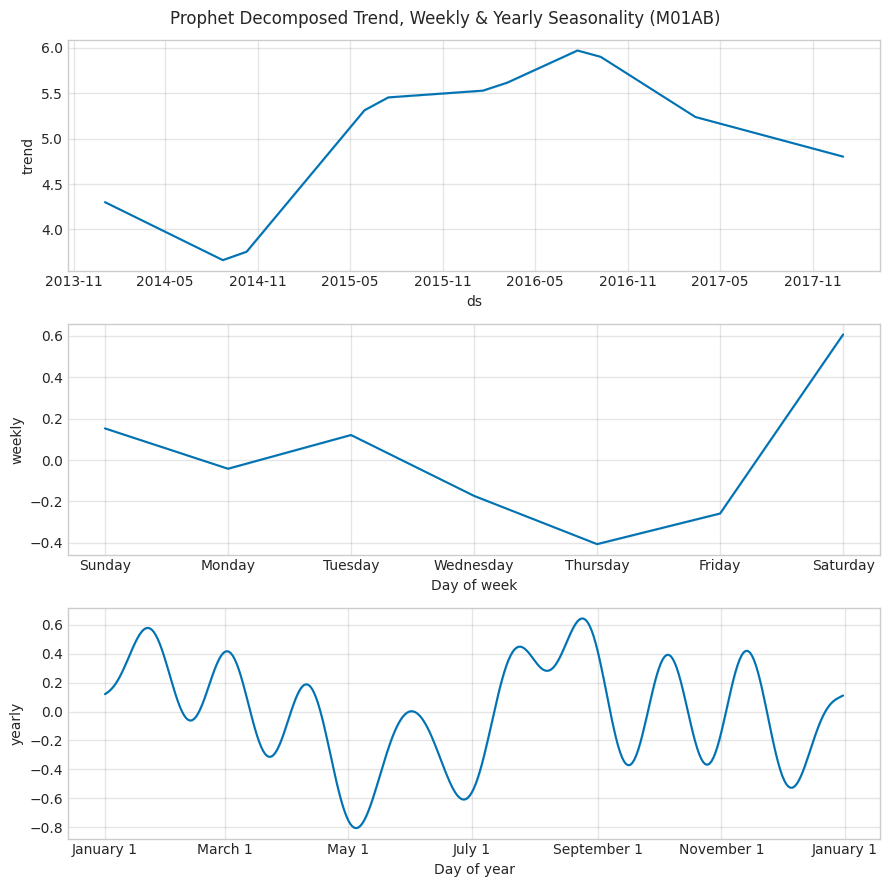

In [5]:
# Step 4: Component Visualization (Decomposed Trend & Seasonality Curves)
fig_comp = m4_tr.plot_components(m4_tr.predict(df_p_tr))
plt.suptitle("Prophet Decomposed Trend, Weekly & Yearly Seasonality (M01AB)", fontsize=12)
plt.tight_layout()
plt.show()


In [6]:
# Step 5: Refit on Train+Val & Forecast 2019 Test Holdout
m4_full = Prophet(
    changepoint_prior_scale=best_cps,
    seasonality_prior_scale=best_sps,
    seasonality_mode=best_smode,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
).fit(df_p_cb)

m4_test_pred = np.clip(m4_full.predict(df_p_ts)['yhat'].values, 0, None)
test_metrics = evaluate_metrics(test_series, m4_test_pred)

print(f"=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 4: PROPHET (TUNED) ===")
for k, v in test_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")

pd.DataFrame({'date': test_series.index, 'pred_Prophet': m4_test_pred}).to_csv('m4_prophet_preds.csv', index=False)


17:31:17 - cmdstanpy - INFO - Chain [1] start processing


17:31:17 - cmdstanpy - INFO - Chain [1] done processing


=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 4: PROPHET (TUNED) ===
  * RMSLE     : 0.5087
  * RMSE      : 2.8309
  * MAE       : 2.1971
  * MAPE (%)  : 75.7209
  * WAPE (%)  : 40.6909
